## Project IND320 - Part 1 
Name: Abisan Sagayathasan 

 Github: Abisan-s , direct link: https://github.com/Abisan-s/IND320-reservoir-dashboard


 Streamlit link: https://ind320-reservoir-dashboard-ogxrr3mcdcp4x3bijhecfy.streamlit.app/



In [1]:
# all the imports used in this task
import pandas as pd
import matplotlib.pyplot as plt


## Importing the dataset

In [2]:
# reads the csv file
df = pd.read_csv("data/reservoirs.csv") 
# shows the first 5 rows of the file. we can make sure that it loaded correctly
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Renaming the column names

In [3]:
# in this part im translating the names from norwegian to english as the task want me to do
df = df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "year",
    "iso_uke": "week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_energy_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_level_previous_week",
    "endring_fyllingsgrad": "change_in_fill_level"
})

df.head() # to check if the names were changed 

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Data types

In [4]:
# i converted the "plain text" into datetime to make it more correct
df["date"] = pd.to_datetime(df["date"])  
# this part shows the structure of the dataset and the data type of each column. relevant later 
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14877 non-null  datetime64[us]
 1   area_type                 14877 non-null  str           
 2   area_number               14877 non-null  int64         
 3   year                      14877 non-null  int64         
 4   week                      14877 non-null  int64         
 5   fill_level                14877 non-null  float64       
 6   capacity_TWh              14877 non-null  float64       
 7   stored_energy_TWh         14877 non-null  float64       
 8   next_publication_date     14877 non-null  str           
 9   fill_level_previous_week  14877 non-null  float64       
 10  change_in_fill_level      14877 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory usage: 1.6 MB


## Data overview

In [5]:
#displaying contents in a relevant way

# here the first rows of the dataset wil show up
display(df.head())

# here the basic information about the numerical columns will show up
display(df.describe())

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


,date,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,fill_level_previous_week,change_in_fill_level
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385


## Sorting after date

In [6]:
# here i sort the data to make it more clean and readable 
df = df.sort_values("date")
# checking if it sorted 
df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657


## Separate plots

Numerical reservoir variables are plotted separately below. In this part
i decided to exclude the categorical and identifier columns because a line plot would not be meaningful for these variables.

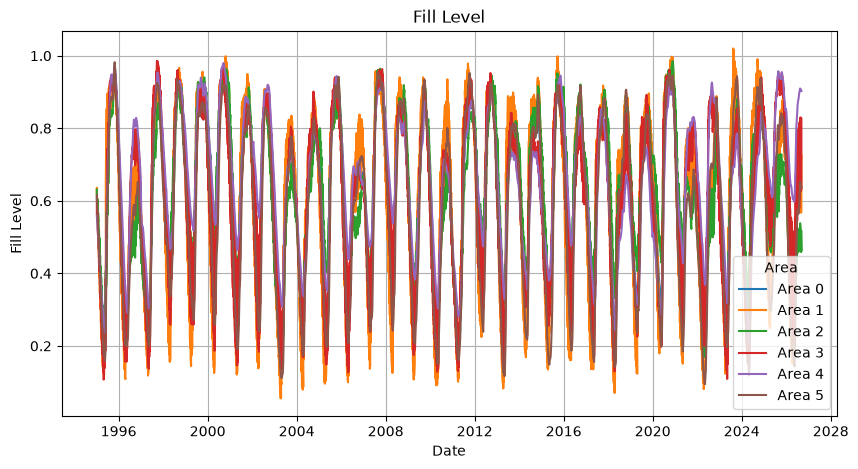

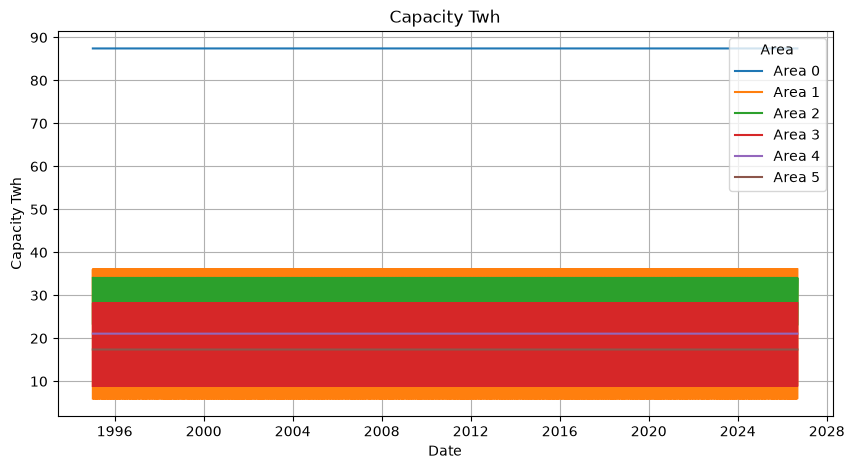

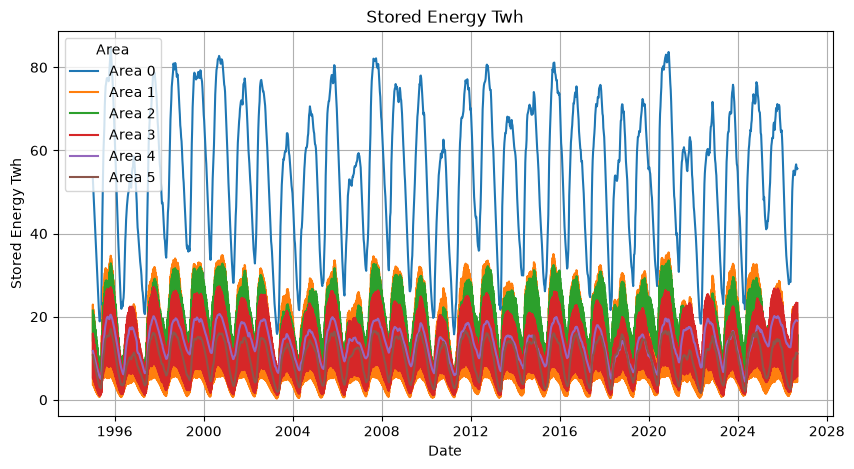

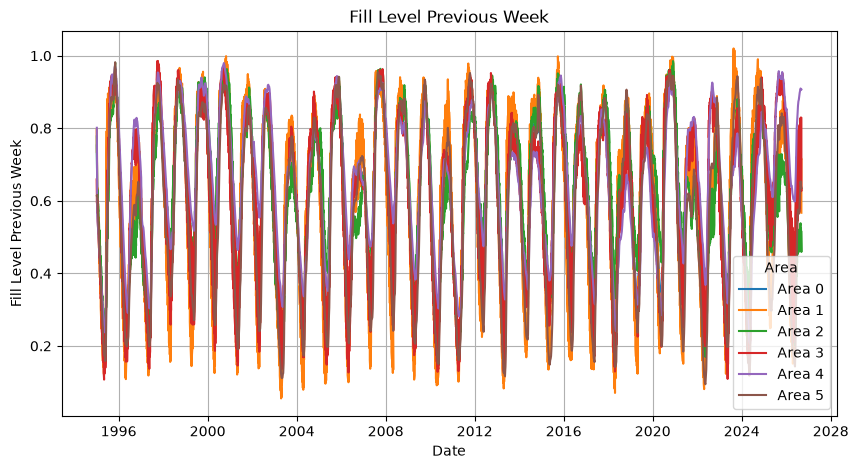

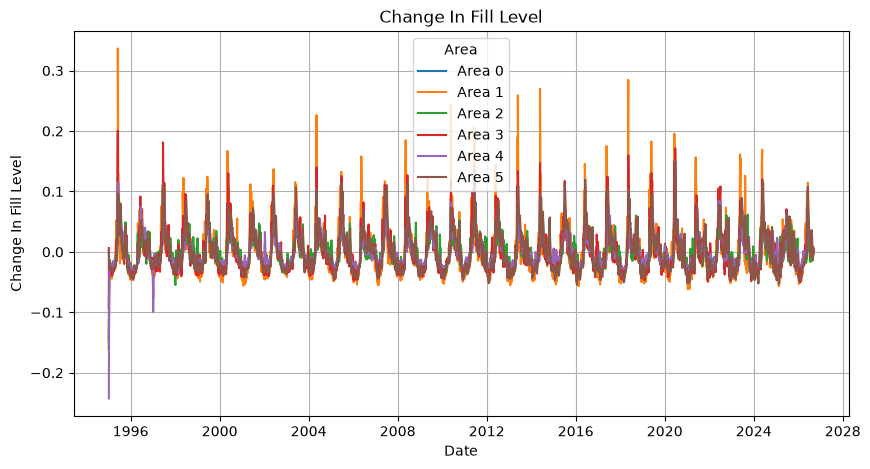

In [7]:
# the plot columns that are included
plot_columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "fill_level_previous_week",
    "change_in_fill_level"
]

for column in plot_columns:
    plt.figure(figsize=(10, 5))

    # plots one line for each reservoir area
    for area in sorted(df["area_number"].unique()):
        area_data = df[df["area_number"] == area]

        plt.plot(
            area_data["date"],
            area_data[column],
            label=f"Area {area}"
        )

    plt.title(column.replace("_", " ").title())
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())
    plt.legend(title="Area")
    plt.grid(True)
    plt.show()



## Combined plot

The numerical variables have different scales and units than the categorical so i decided to 
make them comparable in one figure. There the values are normalized between 0 and 1 and 
the plot is shown separately for each area.

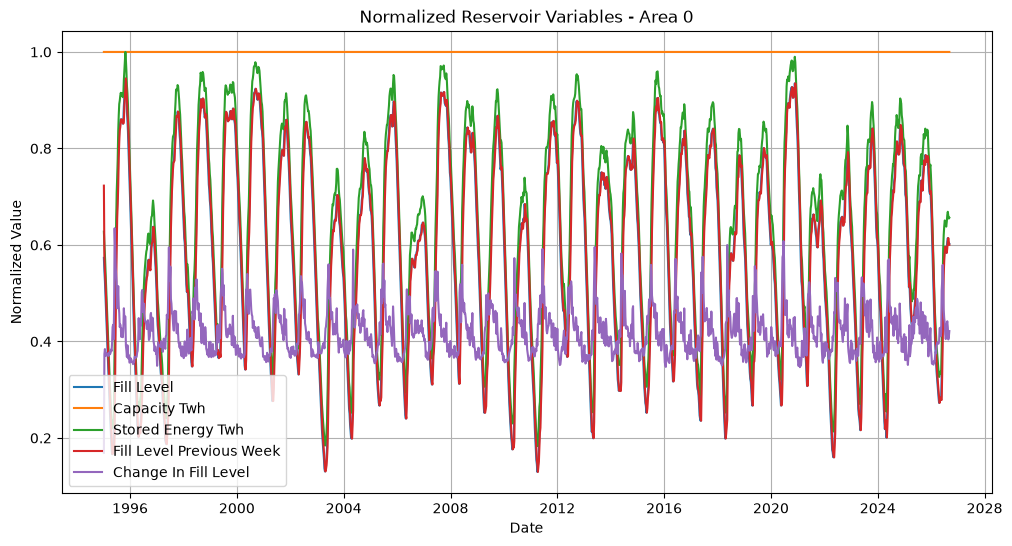

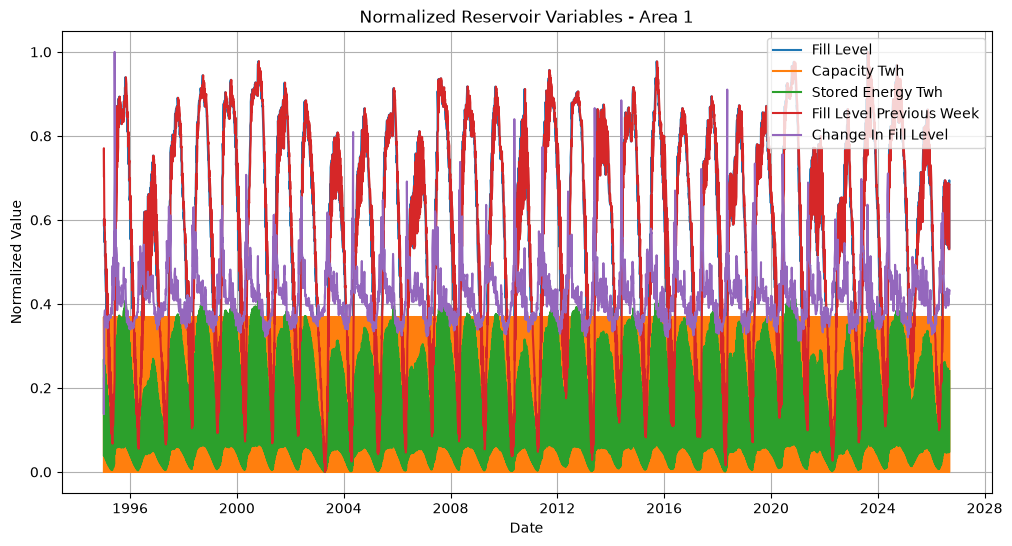

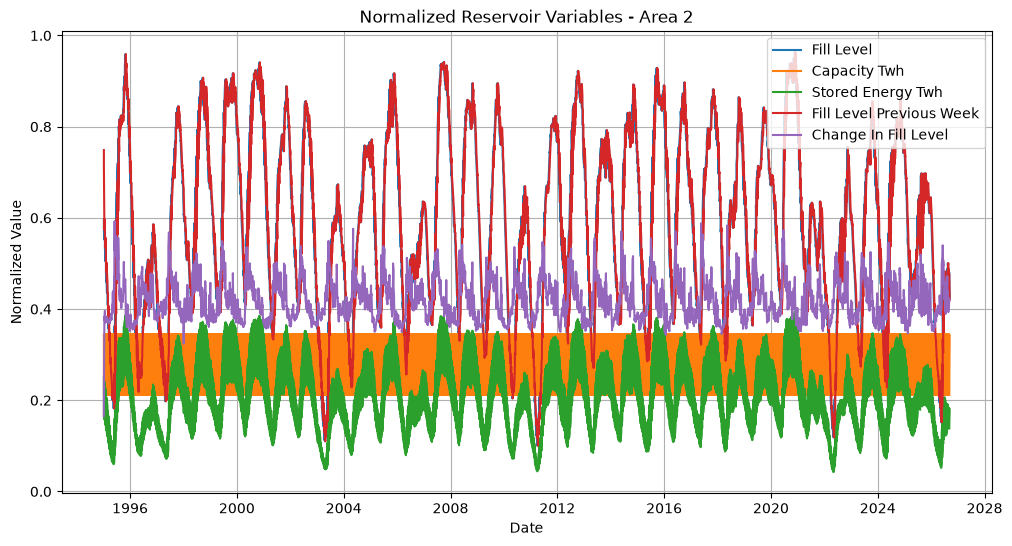

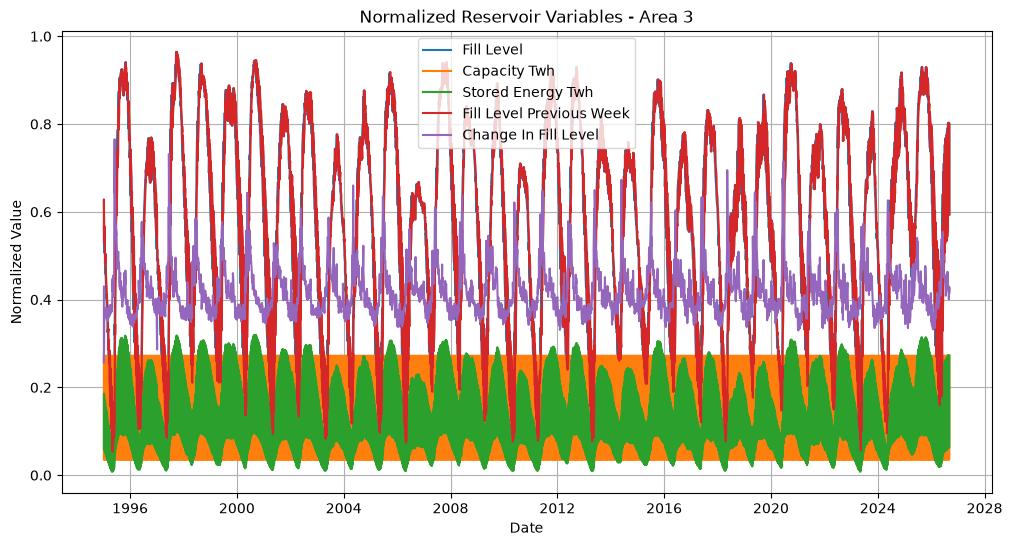

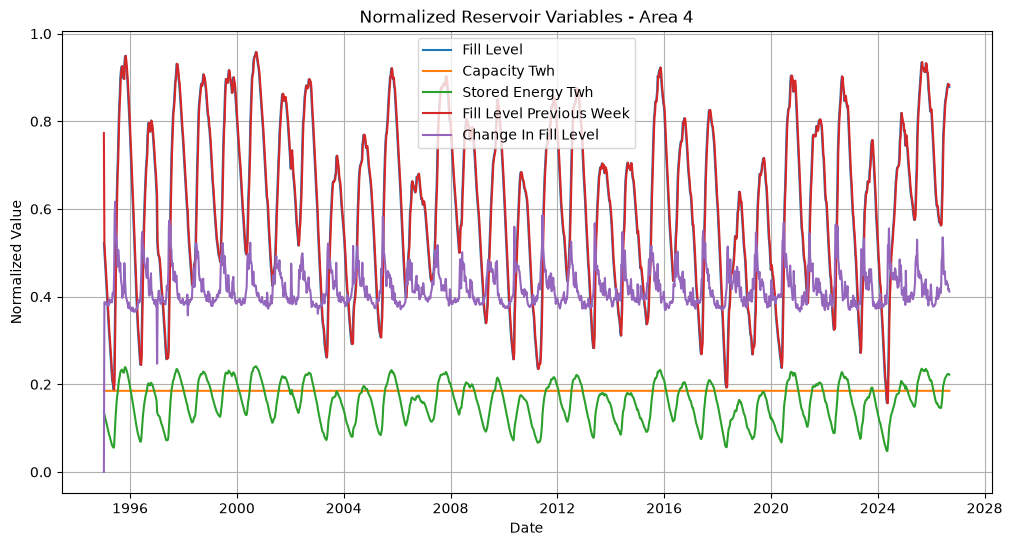

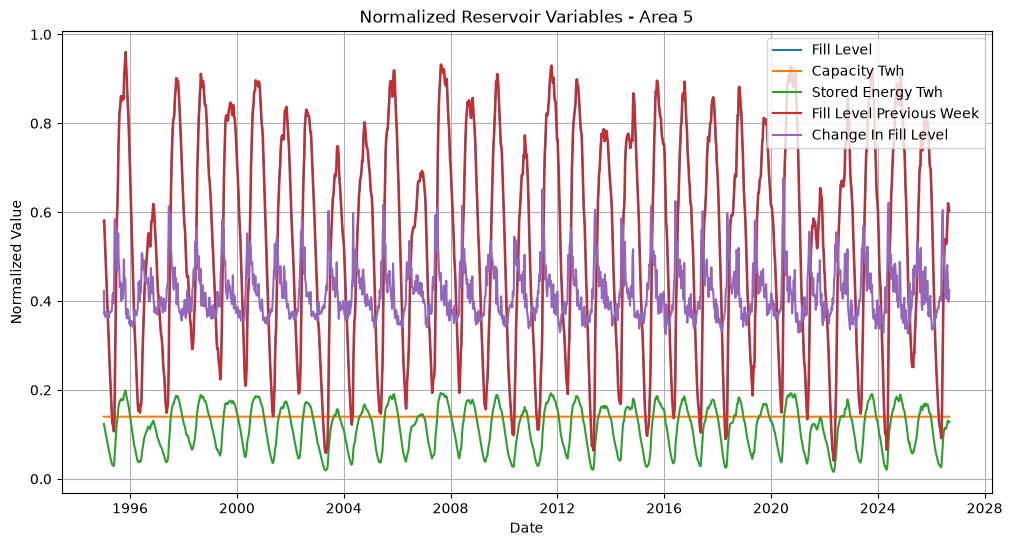

In [8]:
# normalizing the relevant numerical columns so everything is in the same scale
normalized_df = df.copy()

for column in plot_columns:
    min_value = normalized_df[column].min()
    max_value = normalized_df[column].max()

    normalized_df[column] = (
        normalized_df[column] - min_value
    ) / (
        max_value - min_value
    )

# simple plot for showing the different values, what they represent and their value
for area in sorted(normalized_df["area_number"].unique()):
    area_data = normalized_df[normalized_df["area_number"] == area]

    plt.figure(figsize=(12, 6))

    for column in plot_columns:
        plt.plot(
            area_data["date"],
            area_data[column],
            label=column.replace("_", " ").title()
        )

    plt.title(f"Normalized Reservoir Variables - Area {area}")
    plt.xlabel("Date")
    plt.ylabel("Normalized Value")
    plt.legend()
    plt.grid(True)
    plt.show()

## AI Usage 
In the notebook task i used AI to mainly explain and show examples. The tasks were quite straight forward in the notebook part and i just needed a little help with the plot part. AI was mainly used on which plots to use and i asked how i could construate the plots, so i didnt ask for code but rather inspiration/help on how i could visualize it. I still think i couldve done a better job with the plots, but for this part of the project i think its enough, but 100% something i need to work on later.

On the streamlit part of this task i used AI in both explaining and coding. It has a different syntax and i have never used it so it was needed when writing code so i used it to learn. Especially in part 3 where i needed to plot with the different values was very hard so i used AI to explain and learnt in the same time. I copied some lines of code, but not any big parts, because i felt i learn better by understanding and writing code by my self. I understand much better and feel like i can do more the next task, but AI was very much needed.  

## Log 
This is the first part of four assignments. The notebook tasks reminded me alot of the work i did in DAT200 AND 300 so everything wasnt unfamiliar. I started this project by setting up the local  environment for IND320. I installed the basic tools for streamlit and started with the notebook task. 

I imported the reservoir dataset with pandas and checked that the file had loaded correctly. Then i renamed the original norwegian names to english names. The date column was converted to a proper datetime format, and the dataset was sorted chronologically. I used functions such as head(), info() and describe() to inspect the structure, data types and other values in the dataset.

In the plot-part i selected the most relevant numerical variables and created separate plots for each of them. The dataset contains several reservoir areas so i plotted the areas separately to avoid mixing data series. The numerical variables uses different units and scales, so i normalized the values between 0 and 1 before displaying them together. This made the development of the different variables easier to compare. Important to notice that i tried back and forth alot and with the help of AI.

After completing the notebook task, i started with the streamlit application. The app contains four pages as the task says. The home page is just a small introduction and navigation page. The data page loads the CSV file using @st.cache_data and displays a table with one row for each column in the dataset. Numerical columns also use LineChartColumn() to show values from the first month of the data. The plots page contains interactive controls using st.selectbox() and st.select_slider(). This allows the user to choose a reservoir area, select a variable or all variables and select a range of months as they wish. The fourth page is just a dummy page that probably will be developed further in later parts of the project.


Lastly i created a public gitHub repository, pushed the project files and deployed the application using streamlit. I tested both the local and online versions of the app to confirm that the navigation, tables, plots and interactive controls worked as expected. With task 3, the localhost crashing many times was the biggest challenges of this task for me, but in the end the wesite loaded and works as expected, but i know it has a lot of room for improvement.  